In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

print('Libraries imported successfully.')

Libraries imported successfully.


In [4]:
cult = pd.read_excel(r"C:\Users\hp\Downloads\MENTOR SHIP\Mentor_Cult_fit_Ritik.xlsx")

In [6]:
cult.head()

,Unnamed: 0,ActivitySiteID,BookingEndDateTime,BookingStartTime,MaxBookees,Number_Booked,Price,BookingEndMonth,BookingEndDay,Booking_Start_Hour,Booking_Start_Min,Activity,Activity_Time,Activity_Duration
0,0,BRP,2018-04-01,9:00:00,35,29,1499,4,1,9,0,BodyCombat,09:00AM - 10:00AM,60
1,1,BRP,2018-04-01,10:00:00,20,15,1999,4,1,10,0,HattonABC,10:00AM - 11:00AM,60
2,2,HXP,2018-04-01,10:00:00,27,20,1999,4,1,10,0,StudioCyc,10:00AM - 11:00AM,60
3,3,HXP,2018-04-01,9:05:00,27,27,1999,4,1,9,5,StudioCyc,09:05AM - 10:05AM,60
4,4,TSC,2018-04-01,10:00:00,30,13,1299,4,1,10,0,BodyConditioning,10:00AM - 11:00AM,60


In [7]:
cult.shape

(3271, 14)

In [12]:
cult.columns

Index(['ActivitySiteID', 'BookingEndDateTime', 'BookingStartTime',
       'MaxBookees', 'Number_Booked', 'Price', 'BookingEndMonth',
       'BookingEndDay', 'Booking_Start_Hour', 'Booking_Start_Min', 'Activity',
       'Activity_Time', 'Activity_Duration'],
      dtype='object')

In [13]:
cult.isnull().sum()

ActivitySiteID        0
BookingEndDateTime    0
BookingStartTime      0
MaxBookees            0
Number_Booked         0
Price                 0
BookingEndMonth       0
BookingEndDay         0
Booking_Start_Hour    0
Booking_Start_Min     0
Activity              0
Activity_Time         0
Activity_Duration     0
dtype: int64

In [14]:
cult = cult.dropna(
    subset=['Price', 'Number_Booked', 'MaxBookees']
)

In [15]:
cult[['Price', 'Number_Booked', 'MaxBookees']].describe()

,Price,Number_Booked,MaxBookees
count,3271.000000,3271.000000,3271.000000
mean,1852.714460,17.125955,32.224396
std,792.636673,9.515352,15.121398
min,499.000000,1.000000,2.000000
25%,1299.000000,10.000000,24.000000
50%,1499.000000,16.000000,30.000000
75%,2499.000000,24.000000,35.000000
max,3999.000000,64.000000,70.000000


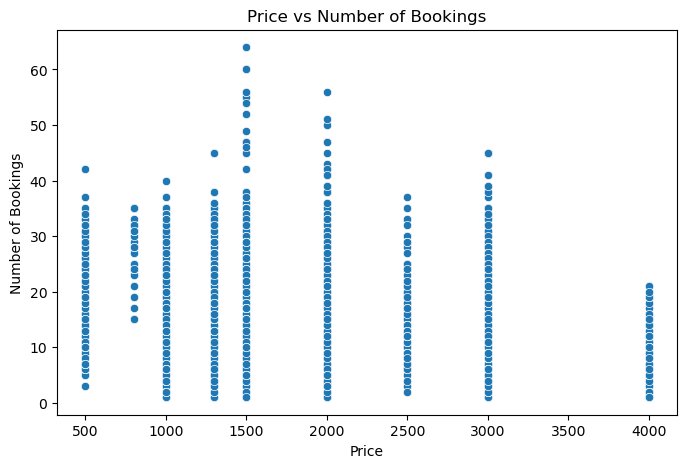

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cult,
    x='Price',
    y='Number_Booked'
)

plt.title('Price vs Number of Bookings')
plt.xlabel('Price')
plt.ylabel('Number of Bookings')

plt.show()

In [18]:
cult['log_price'] = np.log(cult['Price'])

cult['log_booked'] = np.log(cult['Number_Booked'])

cult['log_capacity'] = np.log(cult['MaxBookees'])

In [19]:
cult[
    ['Price', 'log_price',
     'Number_Booked', 'log_booked']
].head()

,Price,log_price,Number_Booked,log_booked
0,1499,7.312553,29,3.367296
1,1999,7.600402,15,2.708050
2,1999,7.600402,20,2.995732
3,1999,7.600402,27,3.295837
4,1299,7.169350,13,2.564949
